<a href="https://colab.research.google.com/github/donkey-king-kong/CSCI-4907---NLU/blob/main/(GWU)_CSCI_4907_NLU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Machine Learning

Machine learning is a branch of artificial intelligence that focuses on developing algorithms and statistical models that allow us to learn from our data and make any predicitons or decisions without explicitly programming it. Machine learning can identify patterns across large datasets that is impossible for the human to do so efficiently. The machine's performance can also be improved over time as they are more exposed to more data or by fine-tuning certain parameters.

## Load all relevant artifacts

In [4]:
import joblib
import torch

# Load train-test split
x_train = joblib.load(r"..\Artifacts\x_train.pkl")
x_test = joblib.load(r"..\Artifacts\x_test.pkl")
y_train = joblib.load(r"..\Artifacts\y_train.pkl")
y_test = joblib.load(r"..\Artifacts\y_test.pkl")
class_names = joblib.load(r"..\Artifacts\class_names.pkl")

print("Data split loaded")

# Load Naive Bayes
nb_model = joblib.load(r"..\Artifacts\naive_bayes_model.pkl")
nb_vectorizer = joblib.load(r"..\Artifacts\naive_bayes_vectorizer.pkl")


print("NB model loaded")
print("NB Vectorizer loaded")

Data split loaded
NB model loaded
NB Vectorizer loaded


### Classifier Report Function

In [ ]:
def Classifier(
    model=None,
    mode="train",
    model_path="model.pkl",
    vectorizer_path="vectorizer.pkl"
):
    """
    mode="train" -> train model and save model + vectorizer
    mode="load"  -> load saved model + vectorizer, no retraining
    """

    if mode == "train":
        # Create and fit TF-IDF vectorizer on training data only
        vectorizer = TfidfVectorizer()
        x_train_vecs = vectorizer.fit_transform(x_train)
        x_test_vecs = vectorizer.transform(x_test)

        model.fit(x_train_vecs, y_train)

        # Save trained model and fitted vectorizer
        joblib.dump(model, model_path)
        joblib.dump(vectorizer, vectorizer_path)

        print(f"Saved model to: {model_path}")
        print(f"Saved vectorizer to: {vectorizer_path}")

    elif mode == "load":
        # Load saved model and fitted vectorizer
        model = joblib.load(model_path)
        vectorizer = joblib.load(vectorizer_path)

        # Transform test text using loaded vectorizer
        x_test_vecs = vectorizer.transform(x_test)

        print(f"Loaded model from: {model_path}")
        print(f"Loaded vectorizer from: {vectorizer_path}")

    else:
        raise ValueError("Mode must be 'train' or 'load'")

    y_pred = model.predict(x_test_vecs)

    print('Accuracy: {:.3f}'.format(accuracy_score(y_test, y_pred)))
    print()
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Plot confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    sb.heatmap(
        conf_matrix,
        annot=True,
        fmt='d',
        cmap=None,
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    return model, vectorizer, y_pred

#### **Naive Bayes Model**

Naive Bayes Model is a simple yet powerful machine learning algorithm used for NLP applications like text classification tasks, particularly in natural language processing (NLP). It's based on Bayes' theorem with the "naive" assumption of feature independence. Despite its simplicity, Naive Bayes often performs well in practice. In our classification, it performs moderately accurate.

Saved model to: .\Artifacts\naive_bayes_model.pkl
Saved vectorizer to: .\Artifacts\naive_bayes_vectorizer.pkl
Accuracy: 0.724

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.99      0.78      1952
           1       0.81      0.91      0.86      1995
           2       0.79      0.82      0.81      1952
           3       0.66      0.32      0.43      2040
           4       0.61      0.35      0.45      2006
           5       0.76      0.97      0.85      1978

    accuracy                           0.72     11923
   macro avg       0.71      0.73      0.70     11923
weighted avg       0.71      0.72      0.69     11923



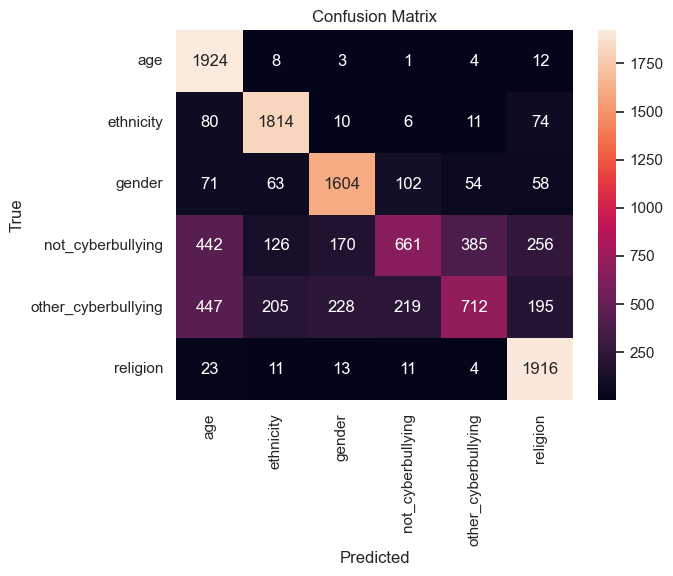

In [ ]:
from sklearn.naive_bayes import MultinomialNB

# Initialize Multinomial Naive Bayes model pass it to the Classifier function
model = MultinomialNB()

nb_model, nb_vectorizer, nb_y_pred = Classifier(
    model=model,
    mode="train",
    model_path=r".\Artifacts\naive_bayes_model.pkl",
    vectorizer_path=r".\Artifacts\naive_bayes_vectorizer.pkl"
)

**ROC Curve**

The ROC curve illustrates the balance between true positive rate (TPR) and false positive rate (FPR) across different thresholds. A model excels when its curve hugs the top-left corner, indicating high TPR and low FPR. Conversely, a curve closer to the diagonal line signifies poor ability to discriminate, no better than random chance.







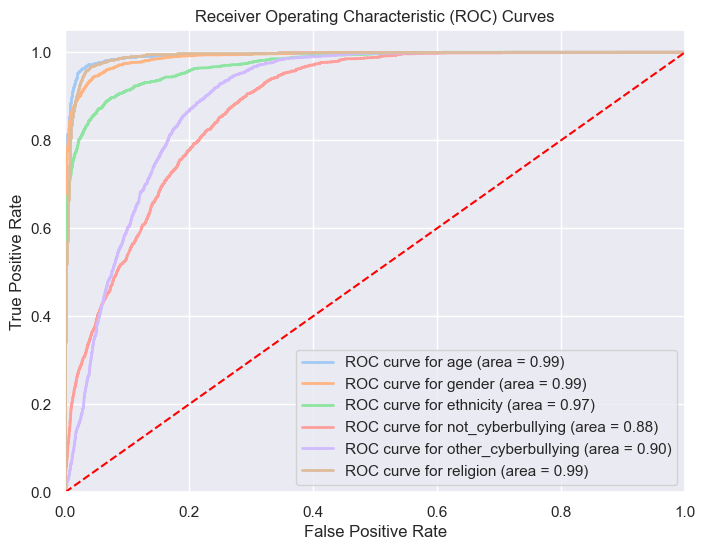

In [ ]:
#ROC Curve

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

#Define Class Labels
class_labels = [ 'age', 'gender', 'ethnicity', 'not_cyberbullying','other_cyberbullying', 'religion']

def plot_roc_curves(model, x_test, y_test):
    # Get the number of classes
    num_classes = len(np.unique(y_test))

    # Initialize the figure
    plt.figure(figsize=(8, 6))

    # Plot ROC curve for each class
    for i in range(num_classes):
        # Treat the current class as positive and the rest as negative
        y_true_class = np.where(y_test == i, 1, 0)

        # Predict probabilities for the current class
        y_probs_class = model.predict_proba(x_test)

        # Calculate false positive rate and true positive rate
        fpr, tpr, _ = roc_curve(y_true_class, y_probs_class[:, i])

        # Calculate area under the curve
        roc_auc = auc(fpr, tpr)

        # Plot ROC curve for the current class
        plt.plot(fpr, tpr, lw=2, label='ROC curve for {} (area = {:.2f})'.format(class_labels[i], roc_auc))

    # Plot random guess line
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')

    # Set plot labels and title
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curves')
    plt.legend(loc='lower right')
    plt.show()

# Call the function with your trained model and test data
vectorizer   = TfidfVectorizer()
vectorizer.fit(df['tweet_clean'])
x_test_vecs  = vectorizer.transform(x_test)
plot_roc_curves(model, x_test_vecs, y_test)

**Learning Curve**

A learning curve is a plot that shows how a model's performance, often measured by accuracy, changes as the size of the training dataset increases. It helps assess if the model benefits from more data and can reveal issues like overfitting or underfitting. Cross-validation scores are often included for a more reliable estimate of performance.

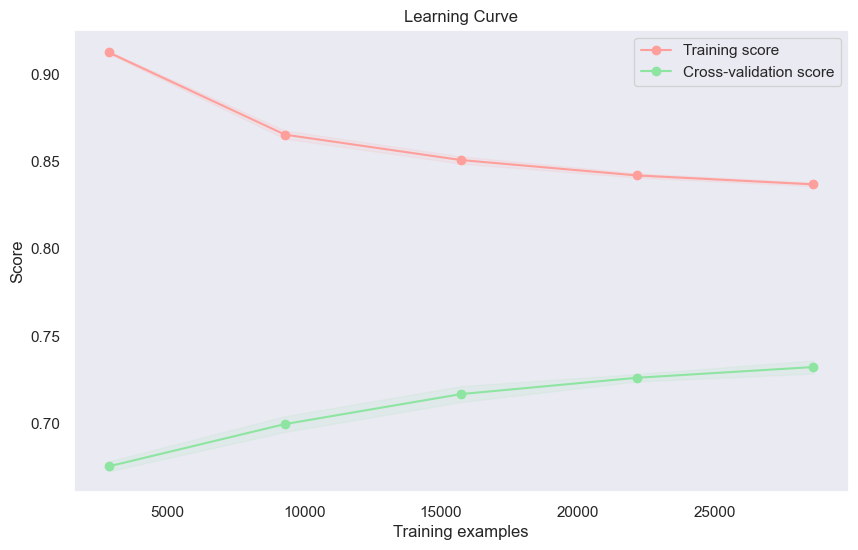

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def plot_learning_curve_multi_class(model, x_train, y_train, class_labels, train_sizes=np.linspace(0.1, 1.0, 5)):
    train_sizes, train_scores, test_scores = learning_curve(
        model, x_train, y_train, train_sizes=train_sizes, cv=5, scoring='accuracy')

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.title("Learning Curve")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

# Call the function with your trained model, training data, and class labels
x_train_vecs = vectorizer.transform(x_train)
plot_learning_curve_multi_class(model, x_train_vecs, y_train, class_labels)

*ADVANTAGES*

- Easy to understand and implement
- Can be trained quickly and make fast predictions
- Can solve multi-class prediction problems

*DISADVANTAGES*

- Lousy estimator